In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from constants import tratados_dir

In [2]:
df_test = pd.read_csv(f'{tratados_dir}/vehiculos_test.csv')
df_train = pd.read_csv(f'{tratados_dir}/vehiculos_train.csv')

,index,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion
0,0,Volkswagen,Passat,Blue,2015.0,Saloon,37723.0,2.0L,Automatic,Diesel,12690.0,5.0,4.0,Flat Tyres,0,2018-04-03,1,23.807,1.0,2018-04-03
1,1,Jaguar,XF,White,2014.0,Saloon,78000.0,2.2L,Automatic,Diesel,13490.0,5.0,4.0,Steering Wheel Shaking,0,2018-05-14,3,73.490,3.0,2018-05-14
2,2,Volkswagen,Polo,Orange,2010.0,Hatchback,44936.0,1.4L,Automatic,Petrol,NaN,5.0,5.0,Alternator Failing,0,2018-08-16,1,160.000,2.0,2018-08-16
3,3,Audi,S5,Black,2014.0,Coupe,29000.0,3.0L,Automatic,Petrol,22990.0,4.0,3.0,Steering Wheel Shaking,0,2018-07-24,1,42.990,1.0,2018-07-24
4,4,Toyota,Yaris,Black,2016.0,Hatchback,18037.0,1.33L,Manual,Petrol,9293.0,5.0,5.0,Electrical Issue,2,2018-05-04,1,28.586,0.5,2018-05-04


## Análisis Univariado:
- Seleccione al menos tres variables y realice un análisis univariable en cada una.
- Proporcione visualizaciones (por ejemplo, histogramas, diagramas de caja) para cada variable seleccionada e interprételas.

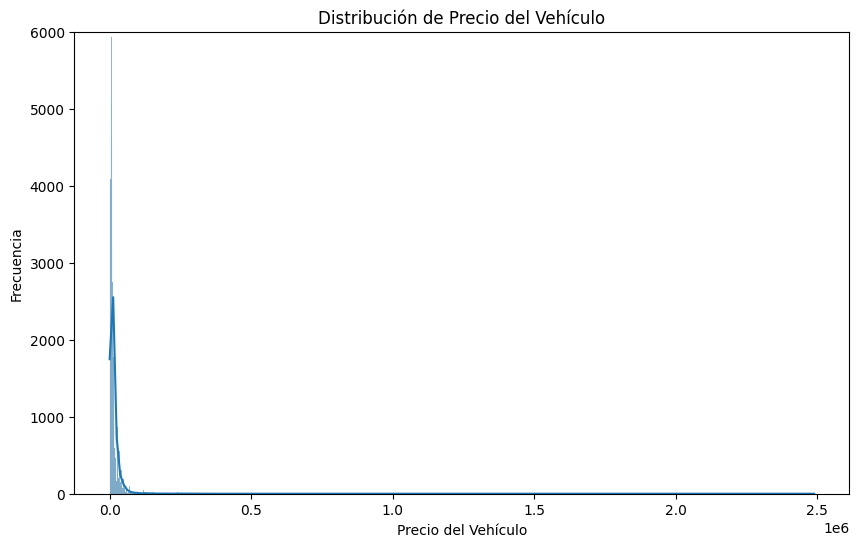

In [154]:
plt.figure(figsize=(10, 6))
sns.histplot(df_train['precio_vehiculo'], kde=True)
plt.title('Distribución de Precio del Vehículo')
plt.xlabel('Precio del Vehículo')
plt.ylabel('Frecuencia')
plt.ylim(0, 6000) # Limitamos el eje y a 6000
plt.show()


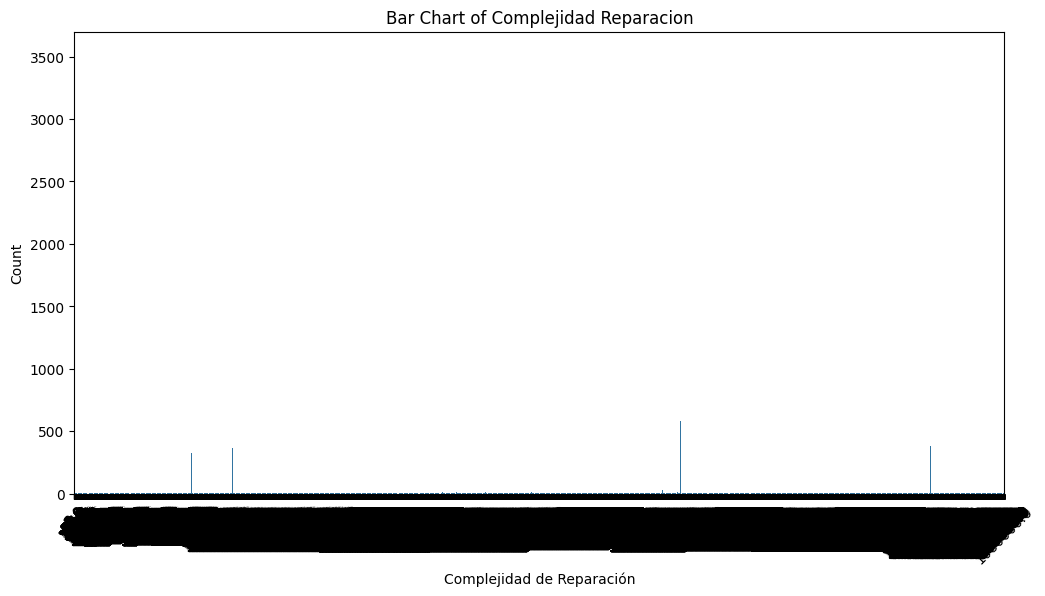

In [155]:
plt.figure(figsize=(12, 6))
sns.countplot(x='millas_recorridas', data=df_train)
plt.title('Bar Chart of Complejidad Reparacion')
plt.xlabel('Complejidad de Reparación')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability if needed
plt.show()


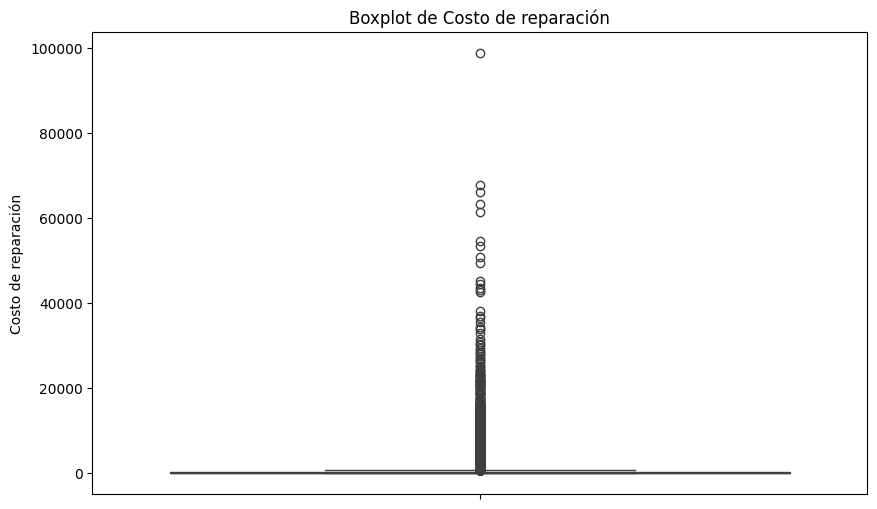

In [156]:
# Assuming df_train is your DataFrame
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_train['costo_reparacion'])
plt.title('Boxplot de Costo de reparación')
plt.ylabel('Costo de reparación')
plt.show()


Correlación

In [157]:
correlaciones = df_train[['fraude','costo_reparacion','precio_vehiculo','millas_recorridas']].corr()
print(correlaciones)

                     fraude  costo_reparacion  precio_vehiculo  \
fraude             1.000000          0.094512         0.075400   
costo_reparacion   0.094512          1.000000         0.299844   
precio_vehiculo    0.075400          0.299844         1.000000   
millas_recorridas -0.020297         -0.126214        -0.308554   

                   millas_recorridas  
fraude                     -0.020297  
costo_reparacion           -0.126214  
precio_vehiculo            -0.308554  
millas_recorridas           1.000000  


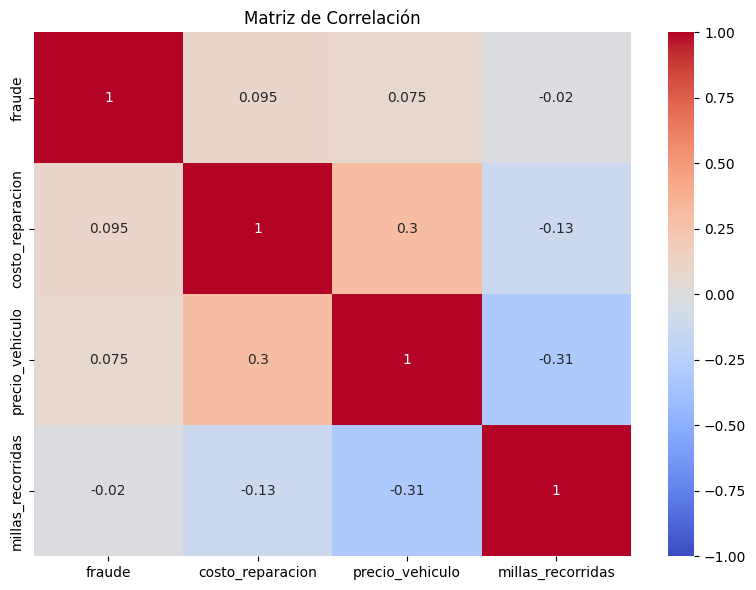

In [158]:
# Visualizar matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.savefig('correlaciones.png')
plt.show()

In [159]:
# Calculate skewness and kurtosis
skewness = df_train[['precio_vehiculo', 'costo_reparacion', 'millas_recorridas']].skew()
kurtosis = df_train[['precio_vehiculo', 'costo_reparacion', 'millas_recorridas']].kurt()

print("Skewness:\n", skewness)
print("\nKurtosis:\n", kurtosis)


Skewness:
 precio_vehiculo      18.522849
costo_reparacion     21.371247
millas_recorridas     1.237257
dtype: float64

Kurtosis:
 precio_vehiculo      1055.779244
costo_reparacion     1009.528468
millas_recorridas       8.480508
dtype: float64
